Считываем данные из файла pulse.txt, содержащего показатели пульса для четырех групп: CB (пациенты до), EB (здоровые до), CA (пациенты после), EA (здоровые после). Удаляем строки с пропущенными значениями, чтобы обеспечить корректность анализа.

Простыми словами:

Открываем файл с данными о пульсе и убираем пустые ячейки, чтобы всё работало правильно.

In [ ]:
from google.colab import files
import pandas as pd

print(" Пожалуйста, выберите файл pulse.txt:")
uploaded = files.upload()
pulse_path = list(uploaded.keys())[0]  # Colab автоматически подставит имя файла

data = pd.read_csv(pulse_path, sep='\s+')
data = data.dropna()
print(f"✅ Загружено {len(data)} строк из {pulse_path}")

 Пожалуйста, выберите файл pulse.txt:


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1347/3905874068.py:8: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(pulse_path, sep='\s+')


Saving pulse.txt to pulse (1).txt
✅ Загружено 30 строк из pulse (1).txt


Проверяем нормальность распределения для каждой группы (CB, EB, CA, EA) с помощью теста Шапиро-Уилка. Тест вычисляет статистику W и p-value. Если p-value > 0.05, гипотеза о нормальности не отвергается(смотрим, похожи ли данные о пульсе на нормальный колокол)

In [ ]:
import scipy.stats as stats
def check_normality(column, name):
    stat, p = stats.shapiro(column)
    print(f'{name}: Statistics={stat:.3f}, p-value={p:.3f}')
    if p > 0.05:
        print(f'{name} распределение нормальное')
    else:
        print(f'{name} распределение не нормальное')
print("Проверка на нормальность:")
check_normality(data['CB'], 'CB (пациенты до)')
check_normality(data['EB'], 'EB (здоровые до)')
check_normality(data['CA'], 'CA (пациенты после)')
check_normality(data['EA'], 'EA (здоровые после)')

Проверка на нормальность:
CB (пациенты до): Statistics=0.971, p-value=0.556
CB (пациенты до) распределение нормальное
EB (здоровые до): Statistics=0.957, p-value=0.253
EB (здоровые до) распределение нормальное
CA (пациенты после): Statistics=0.919, p-value=0.026
CA (пациенты после) распределение не нормальное
EA (здоровые после): Statistics=0.906, p-value=0.012
EA (здоровые после) распределение не нормальное


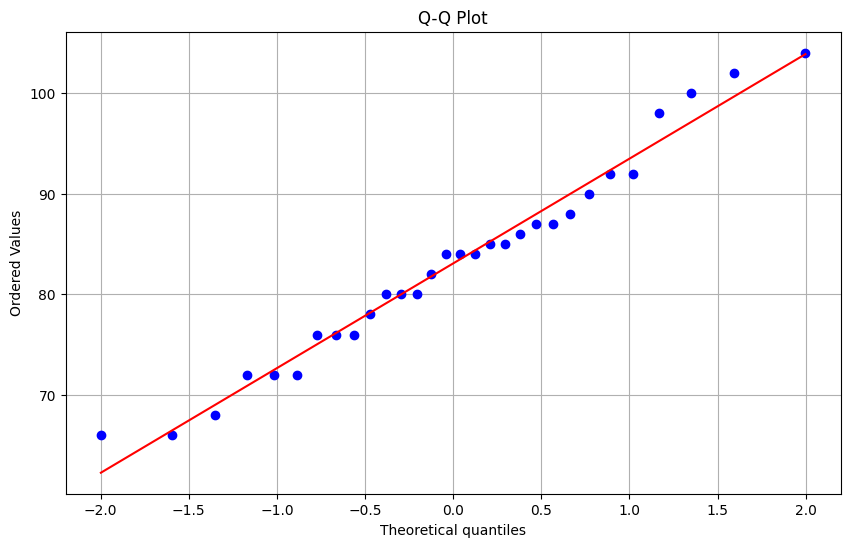

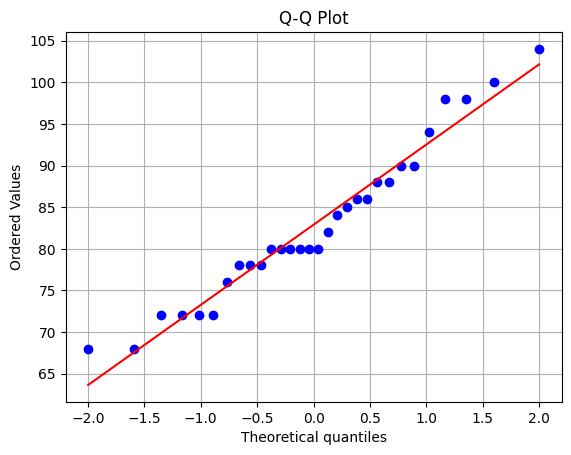

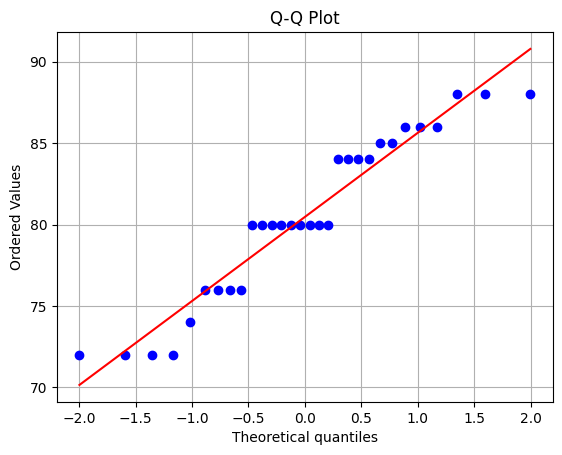

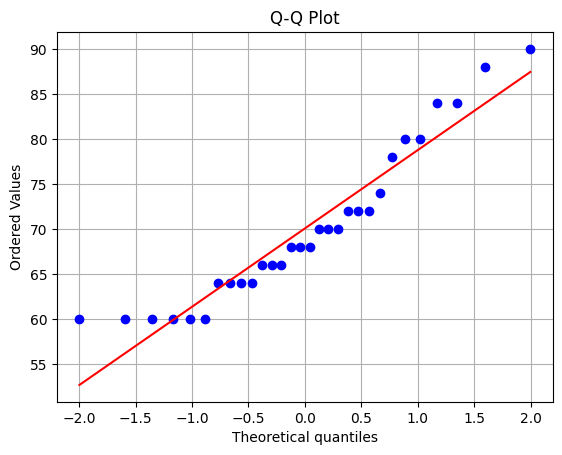

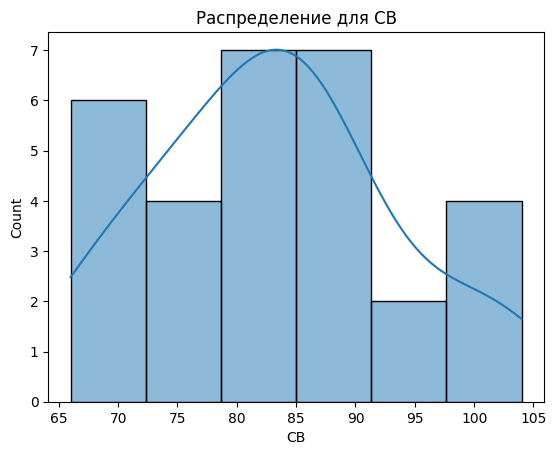

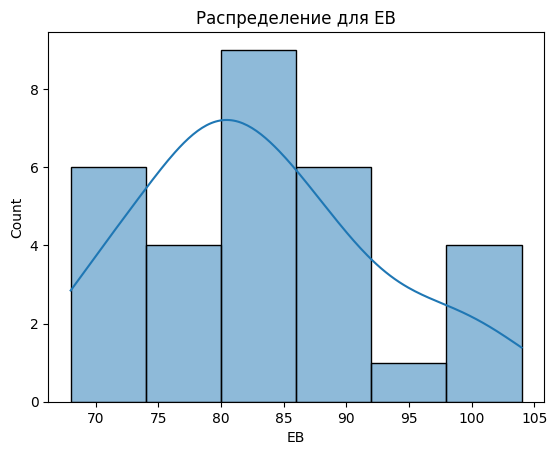

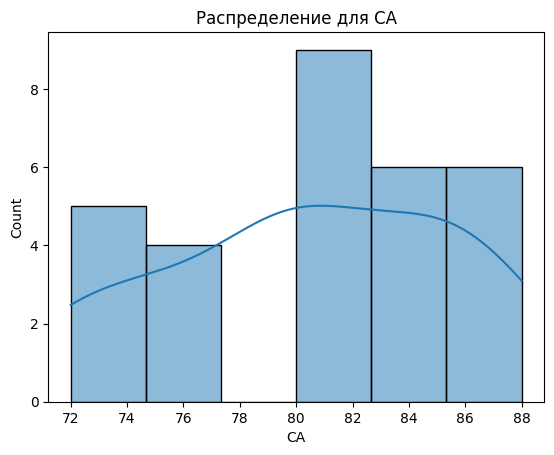

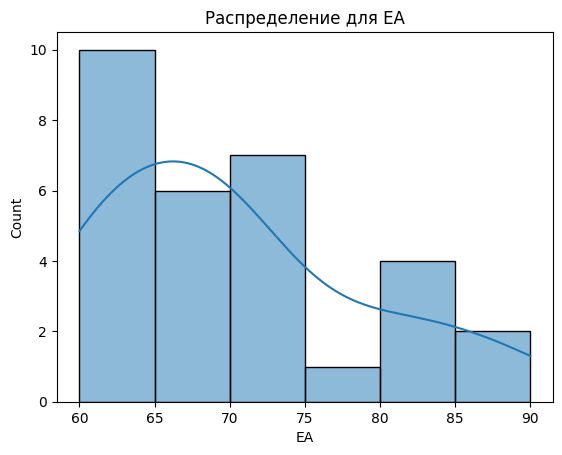

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# График Q-Q plot для проверки нормальности
plt.figure(figsize=(10, 6))
for col in ['CB', 'EB', 'CA', 'EA']:
    stats.probplot(data[col], dist="norm", plot=plt)
    plt.title('Q-Q Plot')
    plt.grid(True)
    plt.show()

# Или можно построить гистограмму:
for col in ['CB', 'EB', 'CA', 'EA']:
    sns.histplot(data[col], kde=True)
    plt.title(f'Распределение для {col}')
    plt.show()

Сравниваем группы "до" и "после" для здоровых (EB vs EA) и пациентов (CB vs CA) с помощью парного t-теста (ttest_rel), так как данные парные (одни и те же люди до и после). Тест вычисляет статистику t и p-value. Если p-value < 0.05, есть значимые различия. Построим коробки с усами для визуализации распределений.


Сравнение групп до и после:
Здоровые (EB vs EA): T-test: Statistics=5.704, p-value=0.000
Есть значимые различия в группах Здоровые (EB vs EA)
Пациенты (CB vs CA): T-test: Statistics=1.137, p-value=0.265
Нет значимых различий в группах Пациенты (CB vs CA)


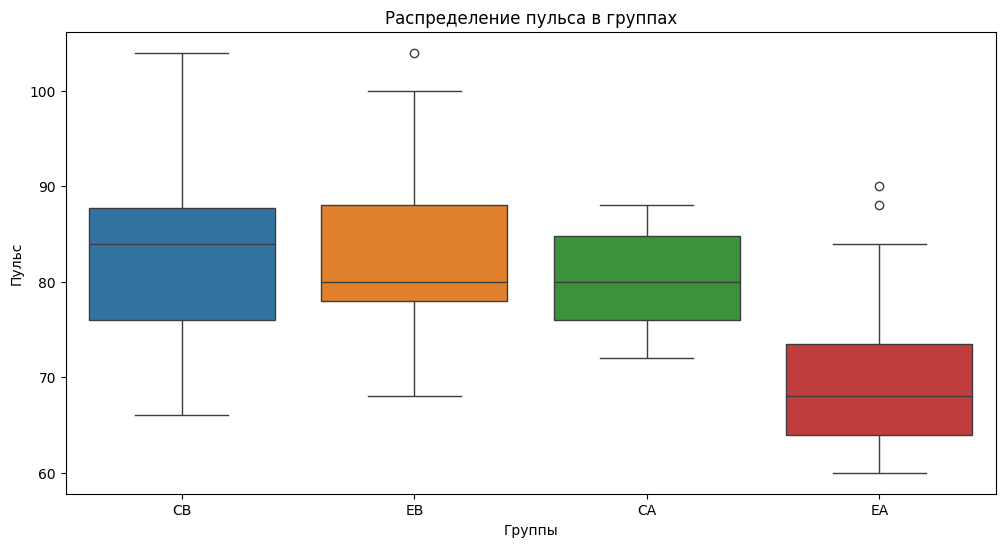

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def compare_groups(before, after, name):
    t_stat, p_value = stats.ttest_rel(before, after)
    print(f'{name}: T-test: Statistics={t_stat:.3f}, p-value={p_value:.3f}')
    if p_value > 0.05:
        print(f'Нет значимых различий в группах {name}')
    else:
        print(f'Есть значимые различия в группах {name}')
print("\nСравнение групп до и после:")
compare_groups(data['EB'], data['EA'], 'Здоровые (EB vs EA)')
compare_groups(data['CB'], data['CA'], 'Пациенты (CB vs CA)')
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[['CB', 'EB', 'CA', 'EA']])
plt.title('Распределение пульса в группах')
plt.xlabel('Группы')
plt.ylabel('Пульс')
plt.show()

Сравниваем группы здоровых и пациентов в каждом состоянии: "до" (EB vs CB) и "после" (EA vs CA). Используем t-тест для независимых выборок (ttest_ind), так как группы разные. Если нормальность не подтверждена, можно использовать непараметрический тест Уилкоксона, но предположим нормальность для простоты. Построим коробки с усами для визуализации.

Простыми словами, Смотрим, отличается ли пульс здоровых от пациентов до и после лекарства. Коробки покажут, как данные распределены.


Сравнение до и после (непараметрическое):
Здоровые: Wilcoxon: Stat=28.500, p-value=0.000
Различия ЕСТЬ (гипотеза отвергается)
Пациенты: Wilcoxon: Stat=134.500, p-value=0.190
Различий НЕТ (гипотеза однородности подтверждается)


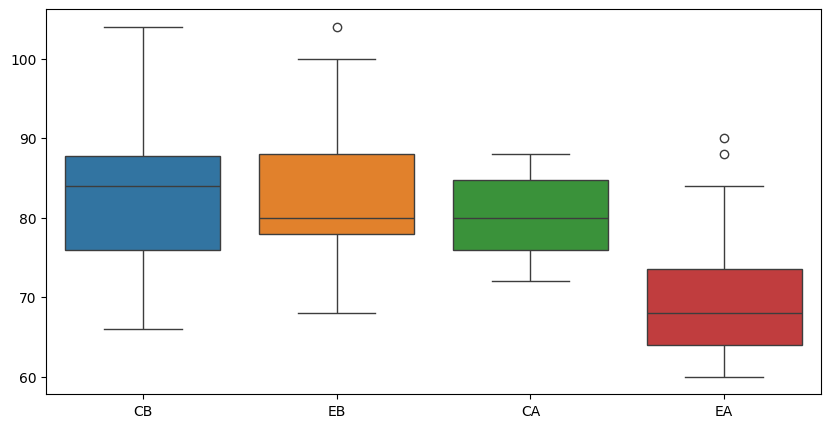

In [ ]:
from scipy.stats import wilcoxon

def compare_paired_nonparametric(group1, group2, name):
    # Используем критерий Уилкоксона для парных выборок
    stat, p_value = wilcoxon(group1, group2)
    print(f'{name}: Wilcoxon: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value > 0.05:
        print(f'Различий НЕТ (гипотеза однородности подтверждается)')
    else:
        print(f'Различия ЕСТЬ (гипотеза отвергается)')

print("\nСравнение до и после (непараметрическое):")
compare_paired_nonparametric(data['EB'], data['EA'], 'Здоровые')
compare_paired_nonparametric(data['CB'], data['CA'], 'Пациенты')

# Boxplot оставляем тот же
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[['CB', 'EB', 'CA', 'EA']])
plt.show()

Делаем выводы об эффективности лекарства на основе результатов t-тестов. Если p-value для CB vs CA < 0.05 и медиана пульса в CA ниже, чем в CB, лекарство снижает пульс у пациентов. Сравнение EB vs EA покажет, влияет ли лекарство на здоровых. Сравнение здоровых и пациентов уточнит различия.


Сравнение групп (непараметрическое):
До (EB vs CB): Mann-Whitney U: p-value=0.911
Различий НЕТ
После (EA vs CA): Mann-Whitney U: p-value=0.000
Различия ЕСТЬ


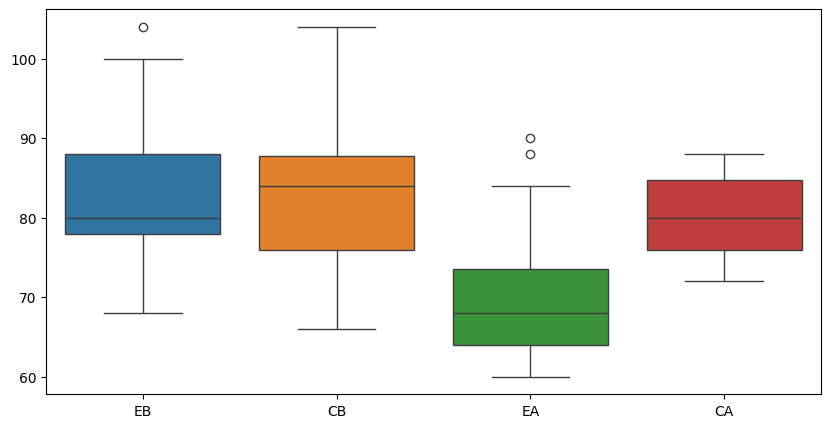

In [ ]:
from scipy.stats import mannwhitneyu

def compare_independent_nonparametric(g1, g2, name):
    # U-критерий Манна-Уитни для независимых выборок
    stat, p_value = mannwhitneyu(g1, g2)
    print(f'{name}: Mann-Whitney U: p-value={p_value:.3f}')
    if p_value > 0.05:
        print(f'Различий НЕТ')
    else:
        print(f'Различия ЕСТЬ')

print("\nСравнение групп (непараметрическое):")
compare_independent_nonparametric(data['EB'], data['CB'], 'До (EB vs CB)')
compare_independent_nonparametric(data['EA'], data['CA'], 'После (EA vs CA)')

# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[['EB', 'CB', 'EA', 'CA']])
plt.show()

Считываем данные из grades.txt, явно задавая имена столбцов ("Группа 1", "Группа 2", "Группа 3", "Группа 4") для корректного распознавания групп. Преобразуем данные в длинный формат, где каждая строка содержит группу и оценку. Формируем таблицу сопряженности, отображающую частоты оценок (3, 4, 5) для каждой группы.

In [ ]:
from google.colab import files
import pandas as pd

print("📂 Выберите файл grades.txt:")
uploaded_grades = files.upload()
grades_path = list(uploaded_grades.keys())[0]

# Читаем файл: табуляция как разделитель, заголовки есть
data_grades = pd.read_csv(grades_path, sep='\t', encoding='utf-16', header=0)

# Если есть предупреждения об encoding, попробуйте:
# data_grades = pd.read_csv(grades_path, sep='\t', header=0, encoding='utf-16')

print("✅ Файл загружен. Первые строки:")
print(data_grades.head())
print(f"\nРазмер: {data_grades.shape[0]} строк × {data_grades.shape[1]} столбцов")

# Преобразуем в длинный формат для таблицы сопряженности
data_long = data_grades.melt(var_name='Группа', value_name='Оценка')
data_long['Оценка'] = pd.to_numeric(data_long['Оценка'], errors='coerce')
data_long = data_long.dropna()

# Таблица сопряженности
contingency_table = pd.crosstab(data_long['Группа'], data_long['Оценка'])
print("\n📊 Таблица сопряженности:")
print(contingency_table)

📂 Выберите файл grades.txt:


Saving grades.txt to grades (2).txt
✅ Файл загружен. Первые строки:
   Группа 1  Группа 2  Группа 3  Группа 4
0         4         4         4         5
1         5         4         4         5
2         3         3         4         3
3         4         4         4         5
4         3         5         3         4

Размер: 30 строк × 4 столбцов

📊 Таблица сопряженности:
Оценка     3   4   5
Группа              
Группа 1  17  11   2
Группа 2  12  15   3
Группа 3  13  12   5
Группа 4   4   7  19


Проверяем гипотезу об отсутствии связи между группой и оценкой с помощью критерия хи-квадрат. Тест вычисляет статистику χ² и p-value. Если p-value < 0.05, гипотеза об отсутствии связи отвергается. Критерий Фишера не используем, так как выборка достаточно большая.

In [ ]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nХи-квадрат: {chi2:.3f}, p-value: {p:.5f}")

# Проверка условия применимости Хи-квадрат (ожидаемые частоты >= 5)
if (expected < 5).any():
    print("Внимание! Есть ячейки с ожидаемой частотой < 5.")
    print("Рекомендуется использовать точный критерий Фишера (stats.fisher_exact), "
          "но для таблиц > 2x2 в scipy он не реализован напрямую. "
          "В данном случае используем Хи-квадрат с осторожностью или симуляцию.")
else:
    print("Все ожидаемые частоты > 5, критерий Хи-квадрат применим.")

if p > 0.05:
    print("Связи между группой и оценкой НЕТ.")
else:
    print("Связь между группой и оценкой ЕСТЬ.")


Хи-квадрат: 36.685, p-value: 0.00000
Все ожидаемые частоты > 5, критерий Хи-квадрат применим.
Связь между группой и оценкой ЕСТЬ.
